In [16]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import os

In [17]:
#set the style
sns.set(style = "whitegrid", palette = "muted")
plt.rcParams["figure.figsize"] = (8, 4)

In [18]:
#load data
df = pd.read_csv("data/default_of_credit_card_clients.csv", header = 1)
df.rename(columns = {"default payment next month": "default"}, inplace = True)
print("Shape:", df.shape)
df.head()

Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [19]:
#basic overview

#dataset info
df.info()

#summary stats
df.describe().T

#check for missing values
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  int64
 3   EDUCATION  30000 non-null  int64
 4   MARRIAGE   30000 non-null  int64
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   3

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

C:\Users\пк\AppData\Local\Temp\ipykernel_11104\2875228776.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = "default", data = df, palette = "Set2")
C:\Users\пк\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\пк\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or ex

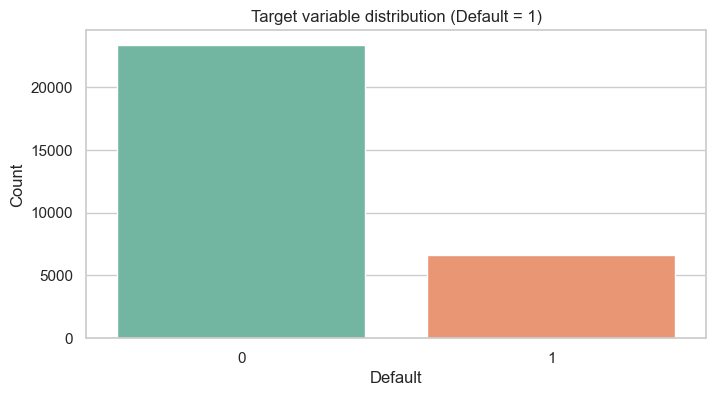

Default rate: 22.12%


In [20]:
#target variable distribution

sns.countplot(x = "default", data = df, palette = "Set2")
plt.title("Target variable distribution (Default = 1)")
plt.xlabel("Default"); plt.ylabel("Count")
plt.show()

default_rate = df["default"].mean() * 100
print(f"Default rate: {default_rate:.2f}%")

In [21]:
#rename columns for readability
df.columns = [c.lower().replace(" ", "_") for c in df.columns]

df = df.rename(columns = {
    "pay_0": "pay_1",      #rename PAY_0 → PAY_1 (payment status of September)
    "sex": "gender"
})

df.head()

,id,limit_bal,gender,education,marriage,age,pay_1,pay_2,pay_3,pay_4,...,bill_amt4,bill_amt5,bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [22]:
#identify coded categorical variables
categorical_cols = [
    "gender",     
    "education",
    "marriage",
    "pay_1", "pay_2", "pay_3", "pay_4", "pay_5", "pay_6"
]

#convert to categorical dtype
for c in categorical_cols:
    df[c] = df[c].astype("category")

In [23]:
#feature types and quick sanity checks

num_cols = df.select_dtypes(include = [np.number]).columns.tolist()
cat_cols = df.select_dtypes(include = ["category"]).columns.tolist()

print("Numeric:", len(num_cols))
print("Categorical:", len(cat_cols))
print("Categorical columns:", cat_cols)

Numeric: 16
Categorical: 9
Categorical columns: ['gender', 'education', 'marriage', 'pay_1', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']


In [24]:
num_cols

['id',
 'limit_bal',
 'age',
 'bill_amt1',
 'bill_amt2',
 'bill_amt3',
 'bill_amt4',
 'bill_amt5',
 'bill_amt6',
 'pay_amt1',
 'pay_amt2',
 'pay_amt3',
 'pay_amt4',
 'pay_amt5',
 'pay_amt6',
 'default']

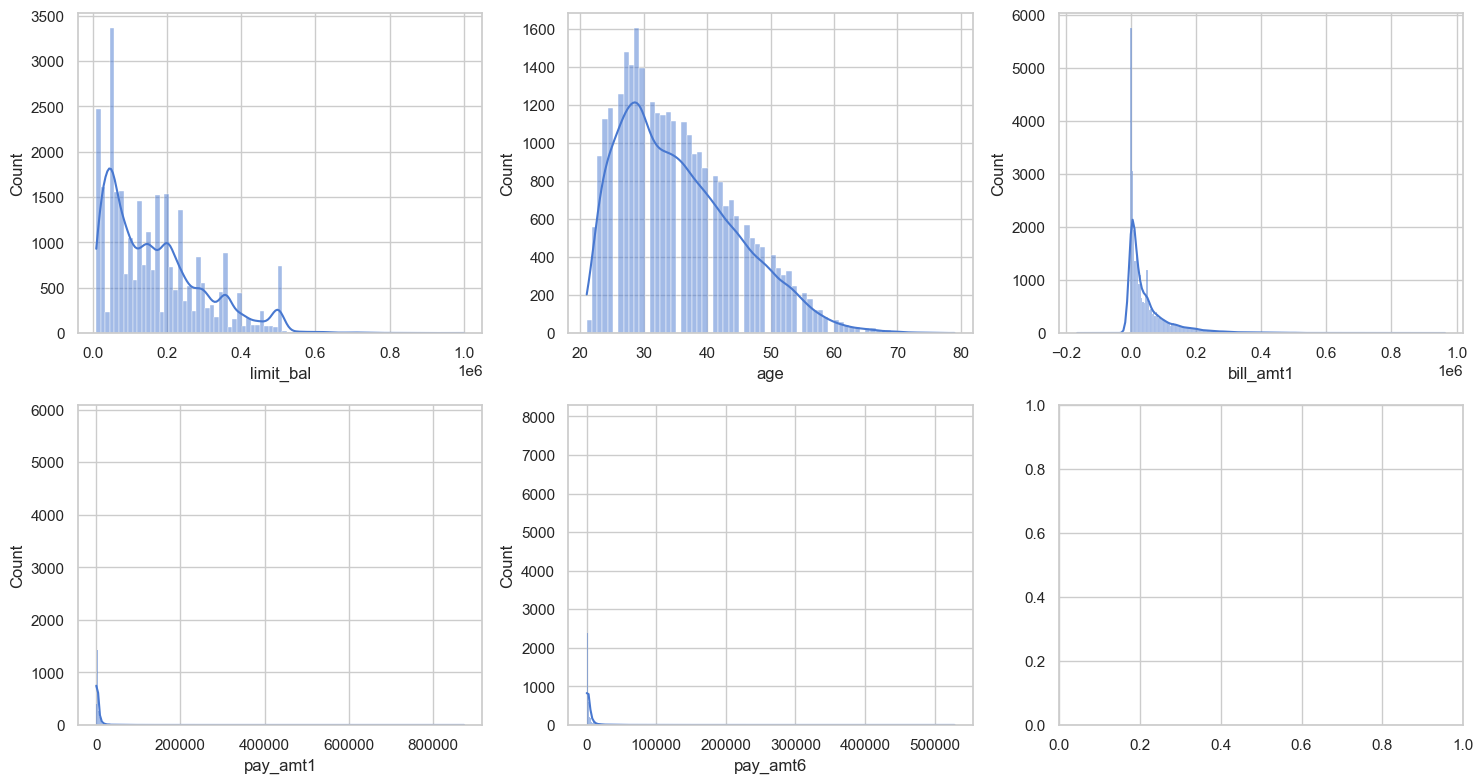

In [25]:
#quick EDA — numerical variables

fig, axes = plt.subplots(2, 3, figsize = (15, 8))
for i, col in enumerate(["limit_bal", "age", "bill_amt1", "pay_amt1", "pay_amt6"]):
    sns.histplot(df[col], kde = True, ax = axes[i//3, i%3])
plt.tight_layout()
plt.show()

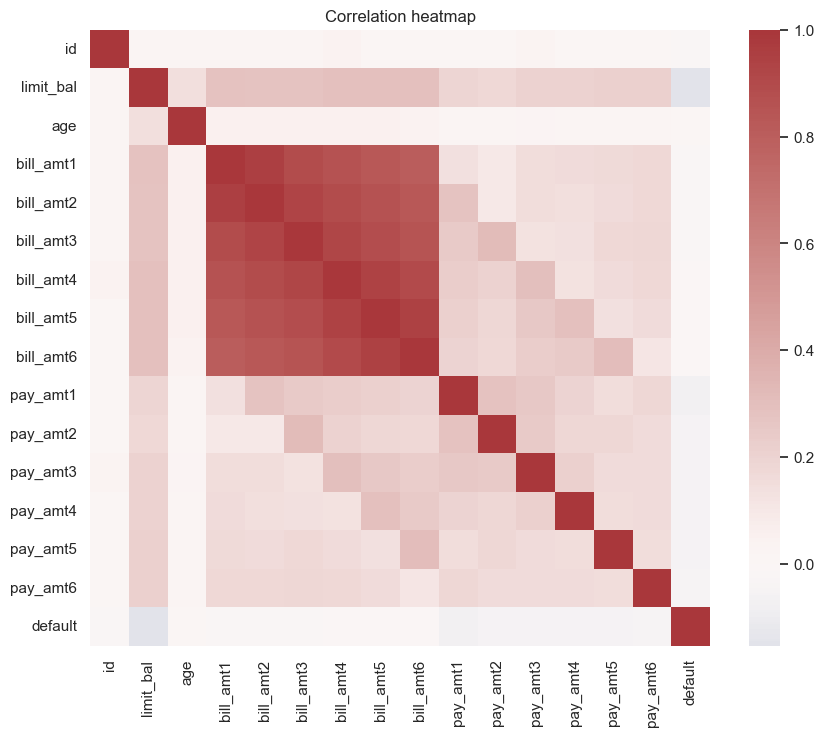

default      1.000000
age          0.013890
bill_amt6   -0.005372
bill_amt5   -0.006760
bill_amt4   -0.010156
id          -0.013952
bill_amt3   -0.014076
bill_amt2   -0.014193
bill_amt1   -0.019644
pay_amt6    -0.053183
Name: default, dtype: float64

In [26]:
#outlier & correlation analysis

#correlation heatmap for numeric variables
corr = df.corr(numeric_only = True)
plt.figure(figsize = (10, 8))
sns.heatmap(corr, cmap = "vlag", center = 0)
plt.title("Correlation heatmap")
plt.show()

#top correlations with default
corr_target = corr["default"].sort_values(ascending = False)
corr_target.head(10)

In [27]:
#clean categorical variables

#gender: 1 = Male, 2 = Female
df["gender"] = df["gender"].map({1 : "Male", 2 : "Female"})

#education: 1 = Graduate, 2 = University, 3 = High school, 4 = Others, 5/6 = Unknown
df["education"] = df["education"].replace({0:4, 5:4, 6:4})
df["education"] = df["education"].map({
    1 : "Graduate school", 2 : "University", 3 : "High school", 4 : "Other"
})

#marriage: 1 = Married, 2 = Single, 3 = Other
df["marriage"] = df["marriage"].replace({0:3})
df["marriage"] = df["marriage"].map({1 : "Married", 2 : "Single", 3 : "Other"})

C:\Users\пк\AppData\Local\Temp\ipykernel_11104\915947113.py:7: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["education"] = df["education"].replace({0:4, 5:4, 6:4})
C:\Users\пк\AppData\Local\Temp\ipykernel_11104\915947113.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["marriage"] = df["marriage"].replace({0:3})


In [28]:
#feature transformations (log & scaling prep)

#log-transform skewed numeric columns (limit, bill, pay amounts)
for col in ["limit_bal", "bill_amt1", "bill_amt2", "bill_amt3", 
            "bill_amt4", "bill_amt5", "bill_amt6",
            "pay_amt1", "pay_amt2", "pay_amt3", 
            "pay_amt4", "pay_amt5", "pay_amt6"]:

    df[f"log_{col}"] = np.log1p(df[col].clip(lower = 0))

df[["limit_bal", "log_limit_bal"]].head()

,limit_bal,log_limit_bal
0,20000,9.903538
1,120000,11.695255
2,90000,11.407576
3,50000,10.819798
4,50000,10.819798


In [29]:
#train/test split & feature lists

X = df.drop(columns = ["default", "id"])
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = 42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Default rate train:", y_train.mean().round(3), "| test:", y_test.mean().round(3))

Train shape: (24000, 36)  Test shape: (6000, 36)
Default rate train: 0.221 | test: 0.221


In [30]:
#save preprocessed dataset

os.makedirs("data/interim", exist_ok = True)
df.to_csv("data/interim/df_preprocessed.csv", index = False)
print("Saved cleaned dataset → data/interim/df_preprocessed.csv")

Saved cleaned dataset → data/interim/df_preprocessed.csv
